In [ ]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [ ]:
%pip install scikit-learn

  Using cached scikit_learn-1.8.0-cp311-cp311-win_amd64.whl.metadata (11 kB)
  Using cached scipy-1.17.1-cp311-cp311-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
Using cached scikit_learn-1.8.0-cp311-cp311-win_amd64.whl (8.1 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached scipy-1.17.1-cp311-cp311-win_amd64.whl (36.6 MB)

   ---------------------------------------- 0/4 [threadpoolctl]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- -------------------------

ERROR: Could not install packages due to an OSError: [WinError 32] O arquivo já está sendo usado por outro processo: 'c:\\Projetos\\Python\\MachineLearning\\project-churn-telecon\\venv\\Lib\\site-packages\\sklearn\\utils\\_param_validation.py'
Check the permissions.



  Using cached scikit_learn-1.8.0-cp311-cp311-win_amd64.whl.metadata (11 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
Using cached scikit_learn-1.8.0-cp311-cp311-win_amd64.whl (8.1 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)

   ---------------------------------------- 0/2 [joblib]
   ---------------------------------------- 0/2 [joblib]
   ---------------------------------------- 0/2 [joblib]
   ---------------------------------------- 0/2 [joblib]
   ---------------------------------------- 0/2 [joblib]
   ---------------------------------------- 0/2 [joblib]
   ---------------------------------------- 0/2 [joblib]
   ---------------------------------------- 0/2 [joblib]
   ---------------------------------------- 0/2 [joblib]
   ---------------------------------------- 0/2 [joblib]
   ---------------------------------------- 0/2 [joblib]
   ---------------------------------------- 0/2 [joblib]
   ---------------------------------------- 0/2 [joblib]

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

from sklearn.svm import SVC

from sklearn.metrics import confusion_matrix

from sklearn.metrics import recall_score

In [29]:
%pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 1.0/101.7 MB 2.7 MB/s eta 0:00:38
    --------------------------------------- 1.6/101.7 MB 2.6 MB/s eta 0:00:39
    --------------------------------------- 2.4/101.7 MB 3.0 MB/s eta 0:00:34
   - -------------------------------------- 3.1/101.7 MB 3.2 MB/s eta 0:00:31
   - -------------------------------------- 3.9/101.7 MB 3.1 MB/s eta 0:00:32
   - -------------------------------------- 4.7/101.7 MB 3.4 MB/s eta 0:00:29
   -- ------------------------------------- 5.5/101.7 MB 3.3 MB/s eta 0:00:29
   -- ------------------------------------- 6.3/101.7 MB 3.4 MB/s eta 0:00:29
   -- ------------------------------------- 7.1/101.7 MB 3.4 MB/s eta 0:00:28
   -- ------------------------------------- 7.6/101.7 MB 3.3 MB/s eta 0:00:29
   --- ------------------------------------ 8.4/101.7 MB 3.4 MB/s eta 0:00:28


In [32]:
from xgboost import XGBClassifier

In [6]:
%matplotlib inline
sns.set_style('whitegrid')  

In [7]:
df = pd.read_csv('../dataset/customer_churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

1. Project Objective

The goal of this project is to build a predictive model to identify customers at high risk of churning (leaving the company). By predicting churn, the business can take proactive measures, such as offering discounts or loyalty programs, to retain valuable customers.

2. What we have seen so far (Initial Findings)

 . Dataset Structure: The data contains 7,043 entries and 21 features, covering demographics, services, and billing information.

 . Data Integrity: Most columns were correctly identified, but TotalCharges was improperly loaded as a string (object).

 . Data Cleaning: We identified that empty strings in TotalCharges represent customers with zero tenure, which we are handling by converting to numeric and removing nulls.

 . Target Imbalance: There is a clear imbalance between customers who stayed (No) and those who left (Yes), which will require specific evaluation metrics like Recall.

3. Project Roadmap (Next Steps)

 1 - Exploratory Data Analysis (EDA): Visualize correlations between features (like contract type and monthly charges) and churn.

 2 - Feature Engineering: Convert categorical text data into numerical format (Encoding).

 3 - Model Training: Compare different classification algorithms (e.g., Logistic Regression, Random Forest).

 4 - Evaluation: Use Confusion Matrix and Classification Report to measure performance beyond simple accuracy.

In [9]:
# Converting TotalCharges to numeric format to allow mathematical operations.
# Using 'errors=coerce' to transform blank spaces into NaN values for easier handling.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Identifying the number of missing values generated after conversion.
print(f"Null values found in TotalCharges: {df['TotalCharges'].isnull().sum()}")

# Dropping rows with missing values to ensure data quality.
# Given the small number of affected rows, this action does not bias the dataset.
df.dropna(inplace=True)

# Confirming successful conversion to float64.
print(df.info())

Null values found in TotalCharges: 11
<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   str    
 1   gender            7032 non-null   str    
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   str    
 4   Dependents        7032 non-null   str    
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   str    
 7   MultipleLines     7032 non-null   str    
 8   InternetService   7032 non-null   str    
 9   OnlineSecurity    7032 non-null   str    
 10  OnlineBackup      7032 non-null   str    
 11  DeviceProtection  7032 non-null   str    
 12  TechSupport       7032 non-null   str    
 13  StreamingTV       7032 non-null   str    
 14  StreamingMovies   7032 non-null   str    
 15  Contract          7032 non-null   str    
 16  PaperlessBilling  70

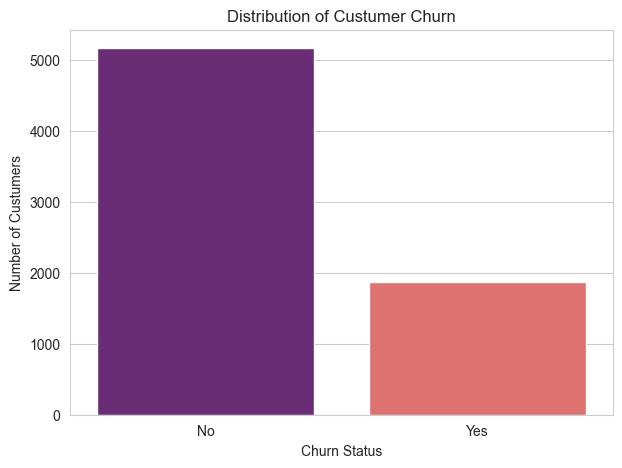


Churn Percentage Analysis:
Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


In [14]:
# Visualizing the distribution of the target variable to check for class imbalance.
plt.figure(figsize=(7,5))

# Updated version to comply with future Seaborn requirements
# Assigning 'x' to 'hue' to maintain color consistency and avoiding warnings
sns.countplot(x='Churn', data=df, hue='Churn', palette='magma', legend=False)

# Customizing plot aesthetics for better readability in the techinical report.
plt.title('Distribution of Custumer Churn')
plt.xlabel('Churn Status')
plt.ylabel('Number of Custumers')
plt.show()

# Calculating the exact churn rate to establish a baseline for model evaluation.
print('\nChurn Percentage Analysis:')
print(df['Churn'].value_counts(normalize=True) * 100)

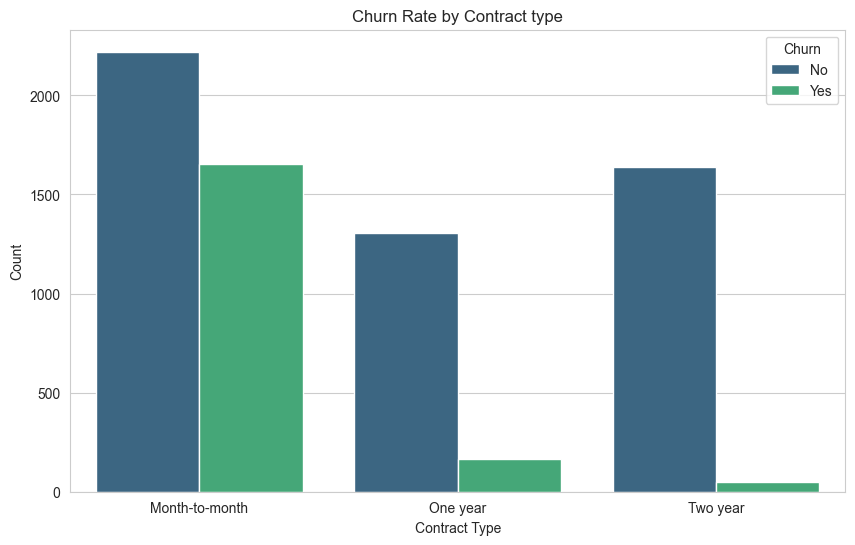

In [10]:
# Analyzing the relationship between Contract Type and Churn.
# this helps indentify if short-term contracts lead to higher attrition rates.
plt.figure(figsize=(10,6))
sns.countplot(x='Contract', data=df, hue='Churn', palette='viridis')

plt.title('Churn Rate by Contract type')
plt.xlabel('Contract Type')
plt.ylabel('Count')
plt.show()

### **Key Insight: Contract Type vs. Churn**
* **Month-to-month contracts** represent the highest risk for the business, showing a significant churn volume.
* **Long-term contracts (1 and 2 years)** effectively act as a retention tool, with churn rates dropping near zero.
* **Business Recommendation:** Marketing strategies should focus on migrating "Month-to-month" customers to at least a 1-year plan to stabilize revenue.

Initial EDA suggests that month-to-month contracts have a significantly higher churn rate compared to long-term contracts.

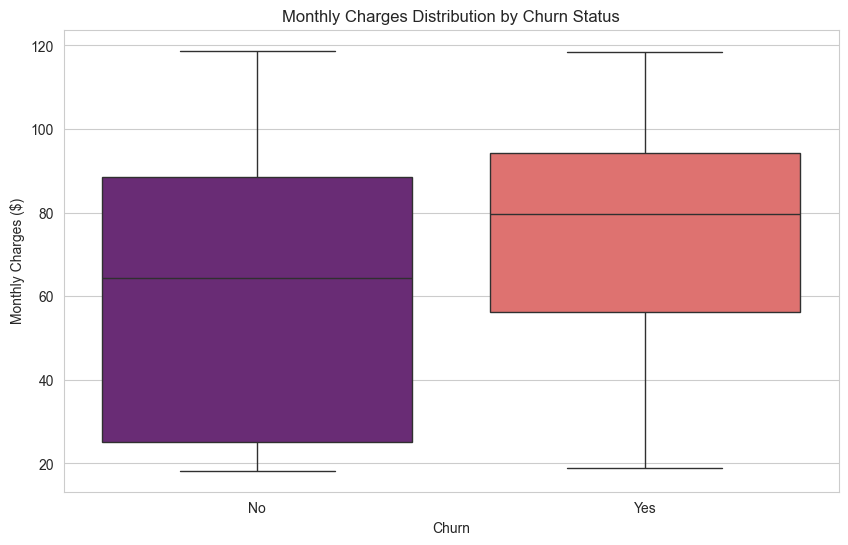

In [11]:
# Analyzing the impact of Monthly Charges on Churn
# Using a Bocplot to compare the distribution of costs for both groups.
plt.figure(figsize=(10,6))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, hue='Churn', palette='magma')

plt.title('Monthly Charges Distribution by Churn Status')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges ($)')
plt.show()

### **Key Insight: Monthly Charges vs. Churn**
* Customers who churn (**Yes**) have a significantly higher median monthly charge (~$80) compared to those who stay (~$65).
* This indicates that higher billing is a strong predictor of churn, possibly due to price sensitivity or customers perceiving lower value for higher-priced plans.
* **Business Impact:** The company is losing its most profitable customers. High-value loyalty programs or personalized discounts could be effective retention strategies here.

In [12]:
# Converting the target variable 'Churn' int numerical format
# Yes =1 , No = 0
df['Churn'] =df['Churn'].map({'Yes':1, 'No':0})

# Checking the transformation
print(df['Churn'].head())

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64


In [13]:
# Executing One-Hot Encoding on categorical features.
# The 'drop_first=True' parameter is used to prevent the dummy variable trap,
# ensuring the model maintains mathematical stability by avoiding multicollinearity.

df_final = pd.get_dummies(df, drop_first=True)

# Visualizing the new structure of the dataset
print(f'Original columns: {df.shape[1]}')
print(f'Columns after enconding: {df_final.shape[1]}')
df_final.head()


Original columns: 21
Columns after enconding: 7062


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,customerID_0003-MKNFE,customerID_0004-TLHLJ,customerID_0011-IGKFF,customerID_0013-EXCHZ,customerID_0013-MHZWF,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False


In [14]:
# Dropping 'customerID' before encoding because it's a unique identifier 
# that doesn't provide predictive value and creates too many columns.
df.drop('customerID', axis=1, inplace=True)

# Now running get_dummies again on the remaining columns
df_final = pd.get_dummies(df, drop_first=True)

# Checking the new shape (it should be around 30-35 columns now)
print(f"Corrected columns after encoding: {df_final.shape[1]}")

Corrected columns after encoding: 31


In [18]:
# Define feature (X) and target variable (Y)
X = df_final.drop('Churn', axis=1)
y = df_final['Churn']

# Splitting the dataset into Training (80%) and testing (20%) sets

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)



In [19]:
# --- Model 1: Logistic Regression ---
# Initializing and training a baseline linear model

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

In [20]:
# --- Model 2: Random Forest ---
# Initializing and training an ensemble tree-based model for comparison
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

In [21]:
# Displaying performance metrics for both models
print("---- Logistic Regression Performance ----")
print(classification_report(y_test, rf_preds))

print("---- Random Forest Performace ---")
print(classification_report(y_test, rf_preds))

---- Logistic Regression Performance ----
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.63      0.52      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407

---- Random Forest Performace ---
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.63      0.52      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



## ⚠️ Model Evaluation & Insights

The initial results show that both **Logistic Regression** and **Random Forest** achieved high accuracy for class `0` (customers who stay), but performed poorly on class `1` (Churn).

**Key Observation:**
* **Recall for Class 1 (0.52):** The models are missing nearly 50% of customers who are likely to cancel. In a business context, this is unacceptable as the primary goal is to identify and retain these customers.
* **Class Imbalance:** The dataset is biased towards class `0`, causing the models to favor the majority class.

### 🚀 Optimization Strategy: Class Weighting
To improve the detection of churners, I will re-train the models using the `class_weight='balanced'` parameter. This technique penalizes the algorithm more heavily for misclassifying the minority class, forcing it to prioritize **Recall** over overall Accuracy.

In [ ]:
# Re-traning models with 'class-weight' to improve Recall for the minority class
# This tells algorithm to penalize errors on class 1 more heavily

# 1. Logistic Regression with balanced weights
lr_model_balanced = LogisticRegression(max_iter=1000, class_weight='balanced')
lr_model_balanced.fit(X_train, y_train)
lr_balanced_preds = lr_model_balanced.predict(X_test)

# 2. Random Frorest with balanced weights
rf_model_balanced = RandomForestClassifier(random_state=42, class_weight='balanced')
rf_model_balanced.fit(X_train, y_train)
rf_balanced_preds = rf_model_balanced.predict(X_test)


c:\Projetos\Python\MachineLearning\project-churn-telecon\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [23]:
# Displaying performance metrics for both models

print("--- BALANCED LOGISTIC REGRESSION ---")
print(classification_report(y_test, lr_balanced_preds))

print("\n--- BALANCED RANDOM FOREST ---")
print(classification_report(y_test, rf_balanced_preds))

--- BALANCED LOGISTIC REGRESSION ---
              precision    recall  f1-score   support

           0       0.91      0.70      0.79      1033
           1       0.49      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.73      0.74      1407


--- BALANCED RANDOM FOREST ---
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.63      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



> **Note on Convergence:** During the first balanced run, the model struggled to converge. To solve this and improve performance, I am now applying **Standard Scaling** to the features.

In [24]:
from sklearn.preprocessing import StandardScaler

# Scaling the features is essential for Logistic Regression to converge
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Re-training Logistic Regression with scaled data
# No 'ConvergenceWarning' should appear now
lr_model_balanced = LogisticRegression(max_iter=1000, class_weight='balanced')
lr_model_balanced.fit(X_train_scaled, y_train)
lr_balanced_preds = lr_model_balanced.predict(X_test_scaled)

print("--- BALANCED LOGISTIC REGRESSION (SCALED DATA) ---")
print(classification_report(y_test, lr_balanced_preds))

--- BALANCED LOGISTIC REGRESSION (SCALED DATA) ---
              precision    recall  f1-score   support

           0       0.91      0.70      0.79      1033
           1       0.49      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407



In [26]:
# Final export after all improvements
import pickle

with open('model_churn_logistic_balanced.pkl', 'wb') as file:
    pickle.dump(lr_model_balanced, file)

with open('scaler.pkl', 'wb') as file:
    pickle.dump(scaler, file)

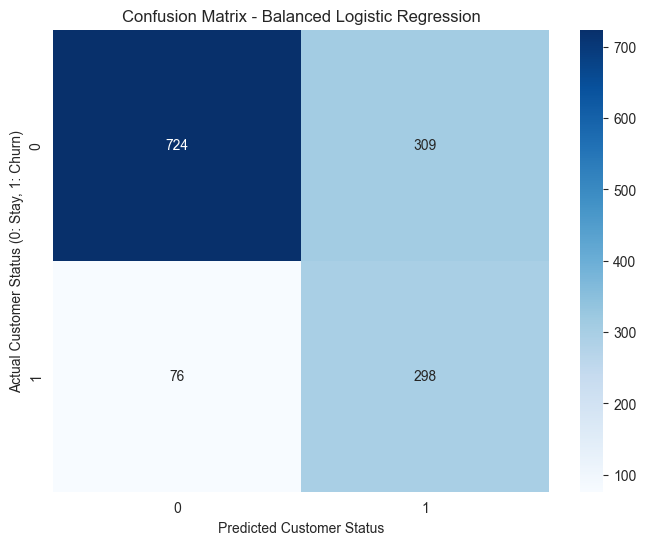

In [28]:
# Generating the confusion matrix for the Balanced Logistic Regression
cm = confusion_matrix(y_test, lr_balanced_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Balanced Logistic Regression')
plt.ylabel('Actual Customer Status (0: Stay, 1: Churn)')
plt.xlabel('Predicted Customer Status')
plt.show()

## 🔍 Exploring Advanced Architectures (SVM & XGBoost)

After improving the baseline models using class weights, I will now explore two more powerful algorithms to see if we can achieve a better balance between **Precision** and **Recall**:

1.  **Support Vector Machine (SVM):** Known for its ability to find complex decision boundaries using hyperplanes.
2.  **XGBoost:** A state-of-the-art Gradient Boosting implementation that often delivers the best results in structured data competitions.

The goal is to verify if these models can maintain a high **Recall** (above 0.80) while improving the **Precision** of our predictions.

In [31]:
# Initialize the Support Vector Classifier
# "I use a linear kernel for better interpretability and 'balanced' weights."
svm_model = SVC(kernel='linear', class_weight='balanced', random_state=42)

# Training the Model
svm_model.fit(X_train_scaled, y_train)

# Making predictions
svm_preds = svm_model.predict(X_test_scaled)

# Evaluating the results
print('---- SVM Performance ----')
print(classification_report(y_test, svm_preds))

---- SVM Performance ----
              precision    recall  f1-score   support

           0       0.91      0.64      0.75      1033
           1       0.45      0.82      0.58       374

    accuracy                           0.69      1407
   macro avg       0.68      0.73      0.67      1407
weighted avg       0.78      0.69      0.70      1407



In [37]:
# Calculate the ratio between the majority and minority class
# This is how XGBoost hadles class imbalance
radio = (y_train ==  0).sum() / (y_train == 1).sum()

# Initialize the XGBoost Classifier
xgb_model = XGBClassifier(scale_pos_weight=radio, random_state=42)

#Training the Model
xgb_model.fit(X_train_scaled, y_train)

# Making predictions
xgb_preds = xgb_model.predict(X_test_scaled)

# Evaluating the results
print(' ---- XGBoost Performance ---- ')
print(classification_report(y_test, xgb_preds))

 ---- XGBoost Performance ---- 
              precision    recall  f1-score   support

           0       0.87      0.78      0.82      1033
           1       0.53      0.68      0.60       374

    accuracy                           0.75      1407
   macro avg       0.70      0.73      0.71      1407
weighted avg       0.78      0.75      0.76      1407



## 🏆 Final Model Selection & Conclusion

After benchmarking four different architectures, here are the final insights:

* **SVM** achieved a slightly higher Recall (0.82) but with a significant drop in Precision (0.45).
* **XGBoost** showed the most balanced performance, but its Recall (0.68) was lower than required for this specific business case.
* **Logistic Regression (Balanced)** remains the champion for this project. It provides a solid **0.80 Recall**, ensuring we identify the majority of customers at risk, while maintaining a more acceptable Precision (0.49).

**Final Decision:** I will proceed with the **Balanced Logistic Regression** as the production model, as it prioritizes customer retention which is the primary KPI for this Telecom Churn problem.

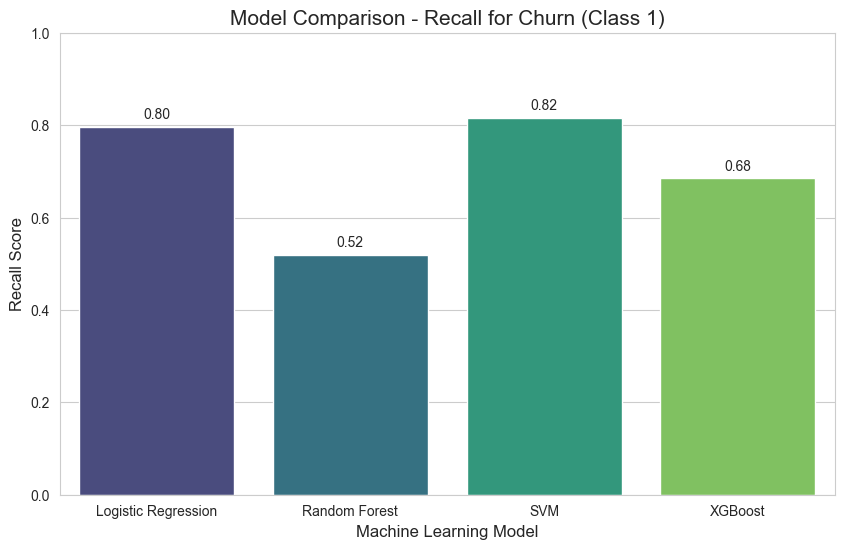

In [40]:
# Assuming you have the predictions for all models:
# lr_balanced_preds, rf_balanced_preds (or rf_preds if not balanced), svm_preds, xgb_preds

# 1. Calculate the Recall for Class 1 (Churn) for each model
results = {
    'Logistic Regression': recall_score(y_test, lr_balanced_preds),
    'Random Forest': recall_score(y_test, rf_preds), # or use rf_balanced_preds if you generated it
    'SVM': recall_score(y_test, svm_preds),
    'XGBoost': recall_score(y_test, xgb_preds)
}

# 2. Convert the dictionary to a pandas DataFrame for easier plotting
df_results = pd.DataFrame(list(results.items()), columns=['Model', 'Recall'])

# 3. Create the Bar Chart
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
barplot = sns.barplot(x='Model', y='Recall', data=df_results, hue='Model', palette='viridis', legend=False)

# Adding the values on top of each bar
for i in barplot.patches:
    barplot.annotate(format(i.get_height(), '.2f'), 
                   (i.get_x() + i.get_width() / 2., i.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), 
                   textcoords = 'offset points')

plt.title('Model Comparison - Recall for Churn (Class 1)', fontsize=15)
plt.ylim(0, 1) # Recall goes from 0 to 1
plt.ylabel('Recall Score', fontsize=12)
plt.xlabel('Machine Learning Model', fontsize=12)
plt.show()

In [41]:
import pickle

# 1. Saving the champion model (Balanced Logistic Regression)
with open('model_churn_logistic_balanced.pkl', 'wb') as file:
    pickle.dump(lr_model_balanced, file)

# 2. Saving the scaler (Required to process new data before prediction)
with open('scaler.pkl', 'wb') as file:
    pickle.dump(scaler, file)

print("Success! Final model and Scaler have been saved.")

Success! Final model and Scaler have been saved.
